In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv(r'C:\upi fraud detection\Data\upi_transactions_raw.csv')

In [10]:

print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df['fraud_flag'].value_counts())
print(df['fraud_flag'].value_counts(normalize=True) * 100)


(30020, 20)
   transaction_id transaction_datetime   sender_id receiver_id  \
0  UPI20260000001  2026-04-09 05:28:33  CUST_07927  RECV_03922   
1  UPI20260000002  2026-01-18 15:37:15  CUST_00572  RECV_03483   
2  UPI20260000003  2026-03-15 16:39:32  CUST_00975  RECV_02801   
3  UPI20260000004  2026-03-14 12:34:25  CUST_02993  RECV_03301   
4  UPI20260000005  2026-02-14 12:18:27  CUST_01395  RECV_01644   

   transaction_amount transaction_type    merchant_category       city  \
0             1673.45              P2P  Individual Transfer     Jaipur   
1             1891.07              P2M             Pharmacy  Bengaluru   
2             1911.14              P2P  Individual Transfer    Chennai   
3              429.38              P2P  Individual Transfer  Ahmedabad   
4             1282.07              P2P  Individual Transfer     Nagpur   

         state device_type   device_id network_type payment_method  \
0    Rajasthan     Android  DEV_012484        Wi-Fi         UPI ID   
1    K

In [11]:
df['transaction_datetime'] = pd.to_datetime(df['transaction_datetime'])
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')

df = df.drop_duplicates(subset='transaction_id')
df = df[df['transaction_amount'] > 0]

df['transaction_hour'] = df['transaction_datetime'].dt.hour
df['transaction_day'] = df['transaction_datetime'].dt.day_name()
df['transaction_month'] = df['transaction_datetime'].dt.month_name()
df['is_night_transaction'] = df['transaction_hour'].between(0, 5).astype(int)


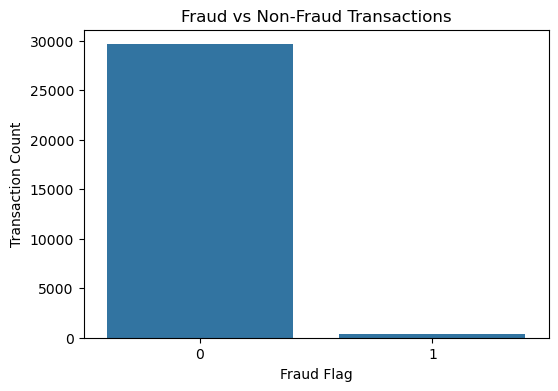

In [12]:
#Create EDA charts
# Fraud vs non-fraud distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fraud_flag')
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Flag')
plt.ylabel('Transaction Count')
plt.show()



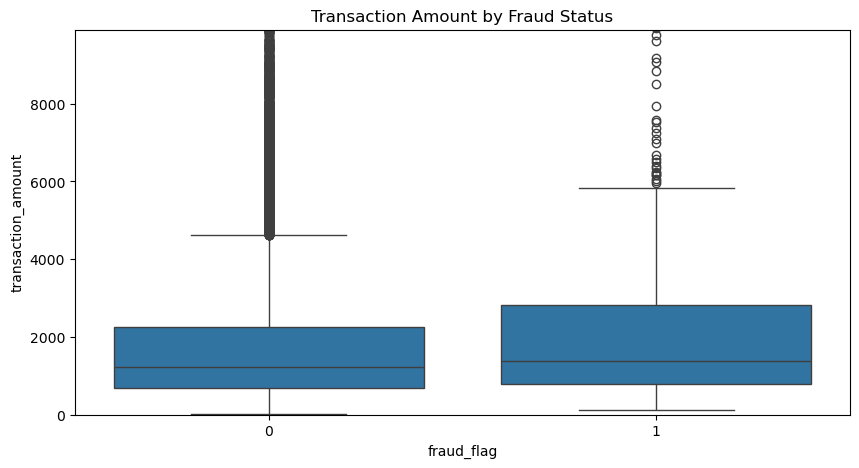

In [13]:
# Amount distribution by fraud status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='fraud_flag', y='transaction_amount')
plt.ylim(0, df['transaction_amount'].quantile(0.99))
plt.title('Transaction Amount by Fraud Status')
plt.show()


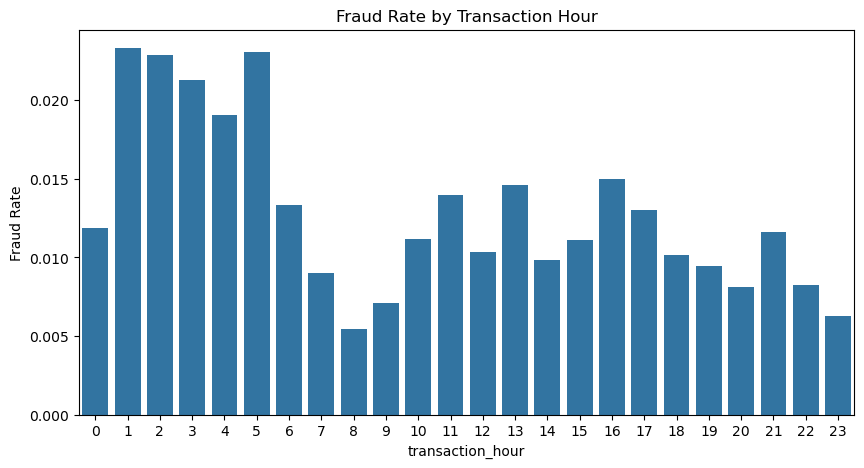

In [14]:
# Fraud rate by hour
hourly_fraud = df.groupby('transaction_hour')['fraud_flag'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_fraud, x='transaction_hour', y='fraud_flag')
plt.title('Fraud Rate by Transaction Hour')
plt.ylabel('Fraud Rate')
plt.show()


In [15]:
#Create features for the model
df['high_value_transaction'] = (
    df['transaction_amount'] >= df['transaction_amount'].quantile(0.90)
).astype(int)

df['risky_new_setup'] = (
    (df['is_new_device'] == 1) &
    (df['is_new_beneficiary'] == 1)
).astype(int)

df['high_failed_attempts'] = (
    df['failed_attempts_24h'] >= 3
).astype(int)

df['account_age_group'] = pd.cut(
    df['customer_age_days'],
    bins=[0, 7, 30, 90, 365, np.inf],
    labels=['0-7 Days', '8-30 Days', '31-90 Days', '91-365 Days', '365+ Days']
)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

features = [
    'transaction_amount', 'transaction_hour', 'previous_transaction_count',
    'customer_age_days', 'failed_attempts_24h', 'is_new_device',
    'is_new_beneficiary', 'is_night_transaction',
    'high_value_transaction', 'risky_new_setup',
    'transaction_type', 'merchant_category', 'city',
    'device_type', 'network_type', 'payment_method'
]

target = 'fraud_flag'
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_features = [
    'transaction_amount', 'transaction_hour', 'previous_transaction_count',
    'customer_age_days', 'failed_attempts_24h', 'is_new_device',
    'is_new_beneficiary', 'is_night_transaction',
    'high_value_transaction', 'risky_new_setup'
]

categorical_features = [
    'transaction_type', 'merchant_category', 'city',
    'device_type', 'network_type', 'payment_method'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ))
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=250,
        max_depth=15,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

logistic_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['transaction_amount',
                                                   'transaction_hour',
                                                   'previous_transaction_count',
                                                   'customer_age_days',
                                                   'failed_attempts_24h',
                                                   'is_new_device',
                                                   'is_new_beneficiary',
                                                   'is_night_transaction',
                                                   'high_value_tran...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['transaction_type',
                                                   'merchant_category', 'city',
                                                   'device_type',
                                                   'network_type',
                                                   'payment_method'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_split=10, n_estimators=250,
                                        n_jobs=-1, random_state=42))])


Logistic Regression
----------------------------------------
Precision: 0.0207
Recall: 0.5584
F1 Score: 0.0399
ROC-AUC: 0.6705
PR-AUC: 0.0323

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.66      0.79      5923
           1       0.02      0.56      0.04        77

    accuracy                           0.66      6000
   macro avg       0.51      0.61      0.42      6000
weighted avg       0.98      0.66      0.78      6000



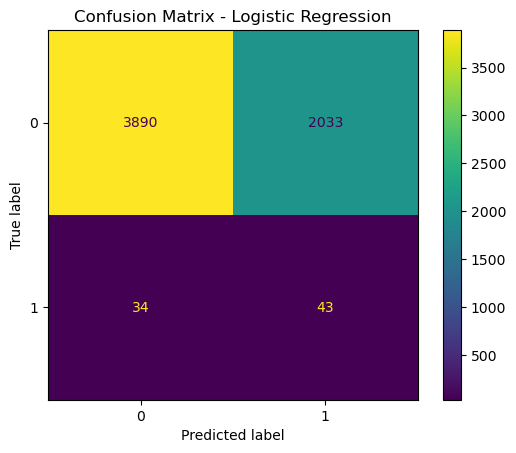


Random Forest
----------------------------------------
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5176
PR-AUC: 0.0216

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5923
           1       0.00      0.00      0.00        77

    accuracy                           0.99      6000
   macro avg       0.49      0.50      0.50      6000
weighted avg       0.97      0.99      0.98      6000



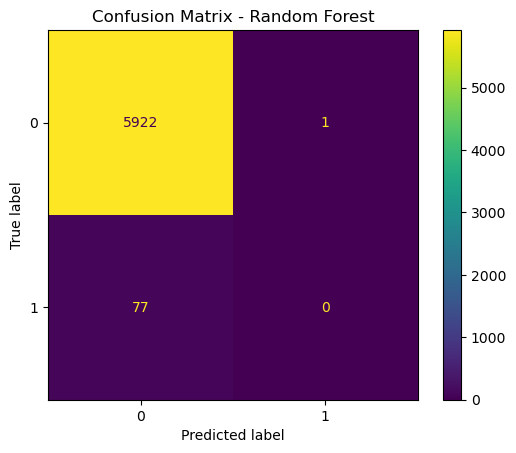

In [17]:
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, ConfusionMatrixDisplay
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f'\n{model_name}')
    print('-' * 40)
    print('Precision:', round(precision_score(y_test, y_pred), 4))
    print('Recall:', round(recall_score(y_test, y_pred), 4))
    print('F1 Score:', round(f1_score(y_test, y_pred), 4))
    print('ROC-AUC:', round(roc_auc_score(y_test, y_prob), 4))
    print('PR-AUC:', round(average_precision_score(y_test, y_prob), 4))
    print('\nClassification Report:\n')
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

evaluate_model(logistic_model, X_test, y_test, 'Logistic Regression')
evaluate_model(rf_model, X_test, y_test, 'Random Forest')


In [18]:
fraud_probability = rf_model.predict_proba(X_test)[:, 1]

threshold = 0.40
y_pred_custom = (fraud_probability >= threshold).astype(int)

print('Precision:', precision_score(y_test, y_pred_custom))
print('Recall:', recall_score(y_test, y_pred_custom))
print('F1 Score:', f1_score(y_test, y_pred_custom))


Precision: 0.0625
Recall: 0.012987012987012988
F1 Score: 0.021505376344086023


In [20]:
df_scored = df.copy()

df_scored['fraud_probability'] = rf_model.predict_proba(df[features])[:, 1]
df_scored['predicted_fraud_flag'] = (
    df_scored['fraud_probability'] >= 0.40
).astype(int)

df_scored['risk_band'] = pd.cut(
    df_scored['fraud_probability'],
    bins=[-0.01, 0.20, 0.50, 0.75, 1.00],
    labels=['Low', 'Medium', 'High', 'Critical']
)


In [24]:
df_scored.to_csv(
    r'C:\upi fraud detection\Data\upi_transactions_scored.csv',
    index=False
)

In [25]:
print("File saved successfully!")
print(df_scored.shape)

File saved successfully!
(30000, 31)
